In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/AI_model')

['figure', 'src', 'model']

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Đã giải nén!")

Đã giải nén!


In [ ]:
import pandas as pd

train = pd.read_csv('/content/data/train.csv')

train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Kích thước dataset


In [ ]:
print("Train shape:", train.shape)

Train shape: (2000, 21)


Thông tin cột

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

### Dịch các tên cột sang tiếng Việt

In [ ]:
column_translations = {
    'battery_power': 'dung_luong_pin',
    'blue': 'co_bluetooth',
    'clock_speed': 'toc_do_cpu',
    'dual_sim': 'ho_tro_2_sim',
    'fc': 'camera_truoc_mp',
    'four_g': 'ho_tro_4g',
    'int_memory': 'bo_nho_trong_gb',
    'm_dep': 'do_day_mm',
    'mobile_wt': 'trong_luong_g',
    'n_cores': 'so_luong_loi_cpu',
    'pc': 'camera_sau_mp',
    'px_height': 'chieu_cao_pixel',
    'px_width': 'chieu_rong_pixel',
    'ram': 'ram_mb',
    'sc_h': 'chieu_cao_man_hinh_cm',
    'sc_w': 'chieu_rong_man_hinh_cm',
    'talk_time': 'thoi_gian_dam_thoai_gio',
    'three_g': 'ho_tro_3g',
    'touch_screen': 'co_man_hinh_cam_ung',
    'wifi': 'co_wifi',
    'price_range': 'khoang_gia'
}

train_vn = train.rename(columns=column_translations)
display(train_vn.head())

,dung_luong_pin,co_bluetooth,toc_do_cpu,ho_tro_2_sim,camera_truoc_mp,ho_tro_4g,bo_nho_trong_gb,do_day_mm,trong_luong_g,so_luong_loi_cpu,...,chieu_cao_pixel,chieu_rong_pixel,ram_mb,chieu_cao_man_hinh_cm,chieu_rong_man_hinh_cm,thoi_gian_dam_thoai_gio,ho_tro_3g,co_man_hinh_cam_ung,co_wifi,khoang_gia
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:

print("Dữ liệu categorical:", train_vn.describe(include='all'))

Dữ liệu categorical:        dung_luong_pin  co_bluetooth   toc_do_cpu  ho_tro_2_sim  \
count     2000.000000     2000.0000  2000.000000   2000.000000   
mean      1238.518500        0.4950     1.522250      0.509500   
std        439.418206        0.5001     0.816004      0.500035   
min        501.000000        0.0000     0.500000      0.000000   
25%        851.750000        0.0000     0.700000      0.000000   
50%       1226.000000        0.0000     1.500000      1.000000   
75%       1615.250000        1.0000     2.200000      1.000000   
max       1998.000000        1.0000     3.000000      1.000000   

       camera_truoc_mp    ho_tro_4g  bo_nho_trong_gb    do_day_mm  \
count      2000.000000  2000.000000      2000.000000  2000.000000   
mean          4.309500     0.521500        32.046500     0.501750   
std           4.341444     0.499662        18.145715     0.288416   
min           0.000000     0.000000         2.000000     0.100000   
25%           1.000000     0.000000    

In [ ]:
train_vn.isnull().sum()

,0
dung_luong_pin,0
co_bluetooth,0
toc_do_cpu,0
ho_tro_2_sim,0
camera_truoc_mp,0
ho_tro_4g,0
bo_nho_trong_gb,0
do_day_mm,0
trong_luong_g,0
so_luong_loi_cpu,0


In [ ]:
missing = train.isnull().sum()
missing_percent = train_vn.isnull().mean() * 100

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_percent
})

missing_df[missing_df['Missing'] > 0]

,Missing,Percent


In [ ]:
print("Số dòng trùng:", train_vn.duplicated().sum())

Số dòng trùng: 0


In [ ]:
train.dtypes

,0
battery_power,int64
blue,int64
clock_speed,float64
dual_sim,int64
fc,int64
four_g,int64
int_memory,int64
m_dep,float64
mobile_wt,int64
n_cores,int64


In [ ]:
numeric_cols = train_vn.select_dtypes(include=np.number).columns

print(numeric_cols)

Index(['dung_luong_pin', 'co_bluetooth', 'toc_do_cpu', 'ho_tro_2_sim',
       'camera_truoc_mp', 'ho_tro_4g', 'bo_nho_trong_gb', 'do_day_mm',
       'trong_luong_g', 'so_luong_loi_cpu', 'camera_sau_mp', 'chieu_cao_pixel',
       'chieu_rong_pixel', 'ram_mb', 'chieu_cao_man_hinh_cm',
       'chieu_rong_man_hinh_cm', 'thoi_gian_dam_thoai_gio', 'ho_tro_3g',
       'co_man_hinh_cam_ung', 'co_wifi', 'khoang_gia'],
      dtype='object')


In [ ]:
numeric_cols = train_vn.select_dtypes(include=np.number).columns

print(numeric_cols)

Index(['dung_luong_pin', 'co_bluetooth', 'toc_do_cpu', 'ho_tro_2_sim',
       'camera_truoc_mp', 'ho_tro_4g', 'bo_nho_trong_gb', 'do_day_mm',
       'trong_luong_g', 'so_luong_loi_cpu', 'camera_sau_mp', 'chieu_cao_pixel',
       'chieu_rong_pixel', 'ram_mb', 'chieu_cao_man_hinh_cm',
       'chieu_rong_man_hinh_cm', 'thoi_gian_dam_thoai_gio', 'ho_tro_3g',
       'co_man_hinh_cam_ung', 'co_wifi', 'khoang_gia'],
      dtype='object')


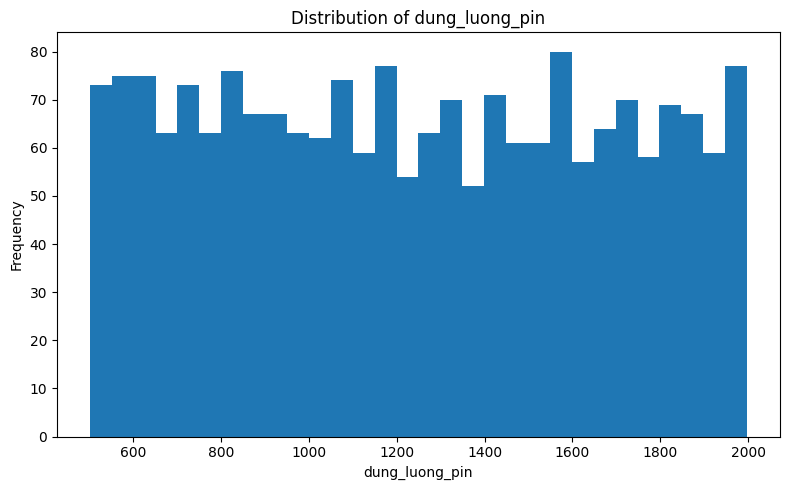

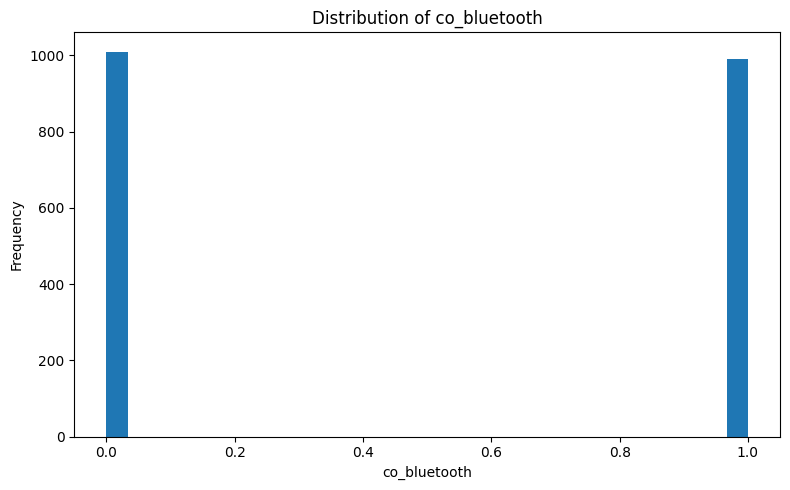

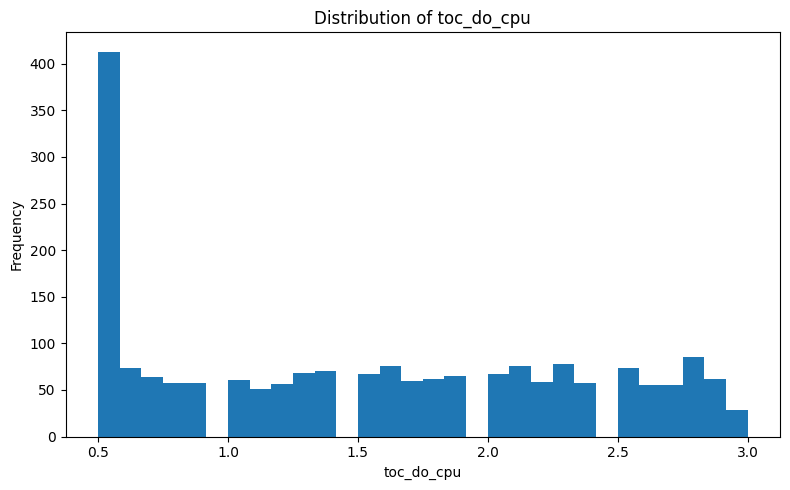

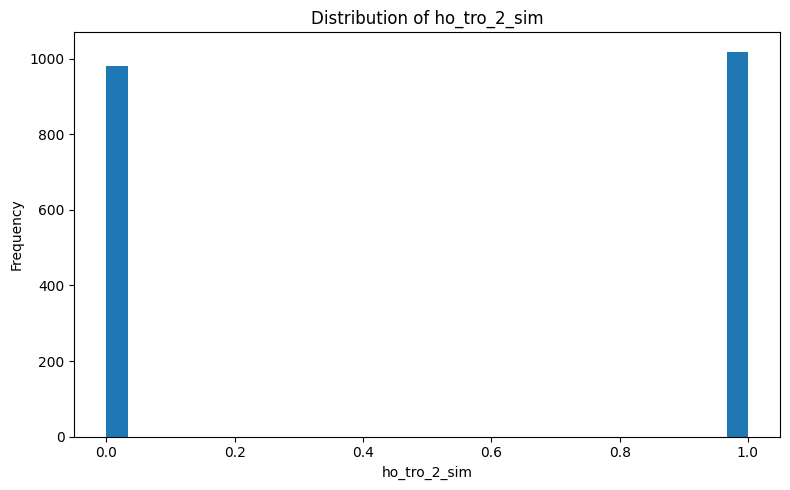

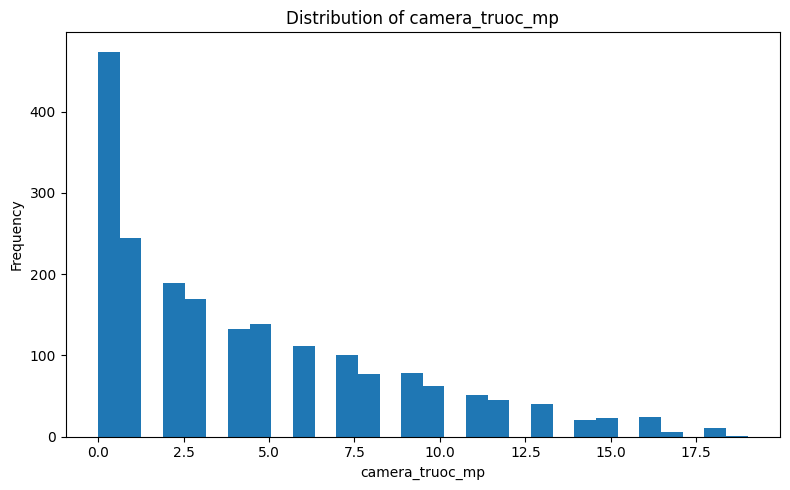

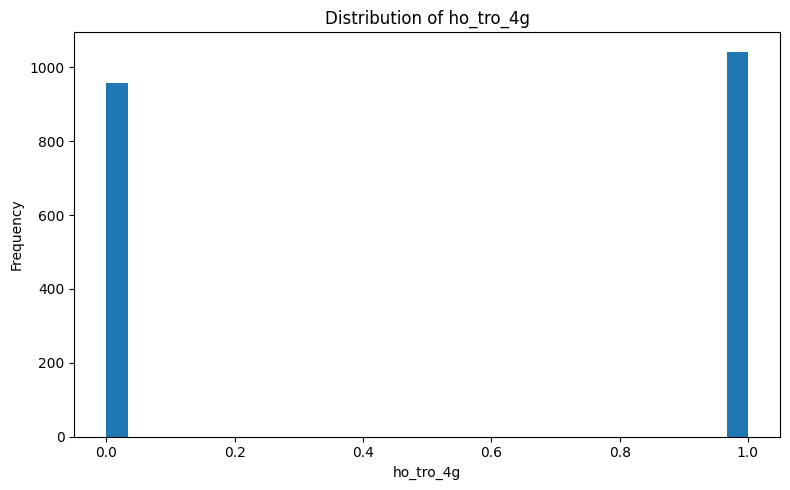

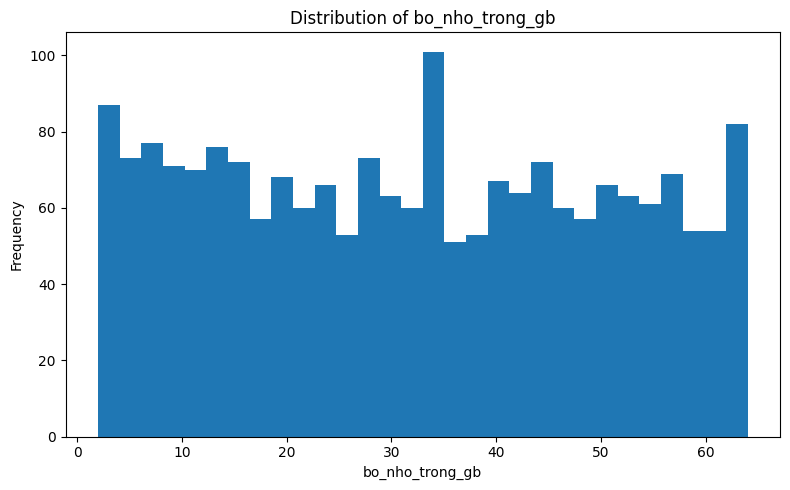

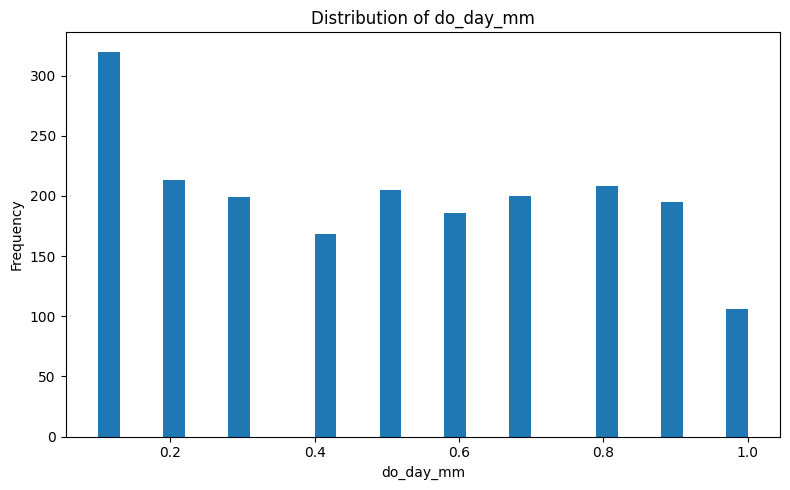

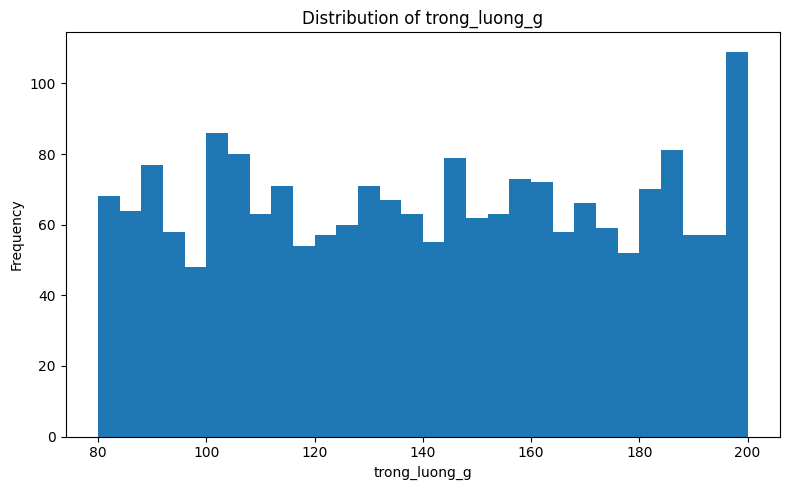

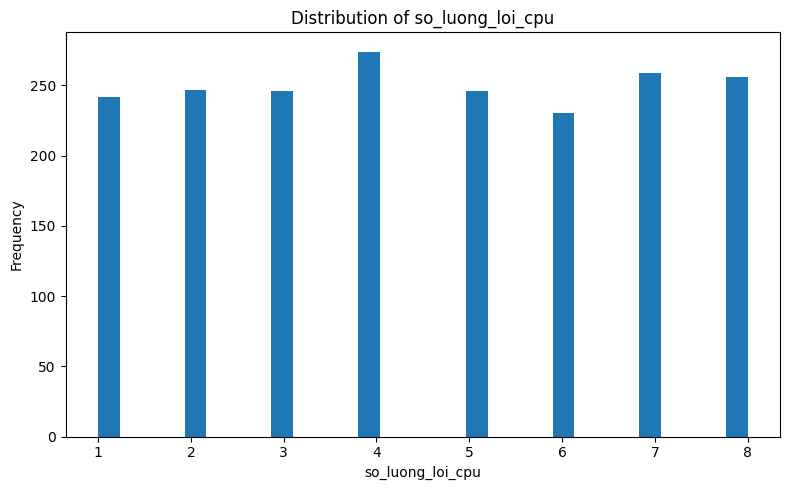

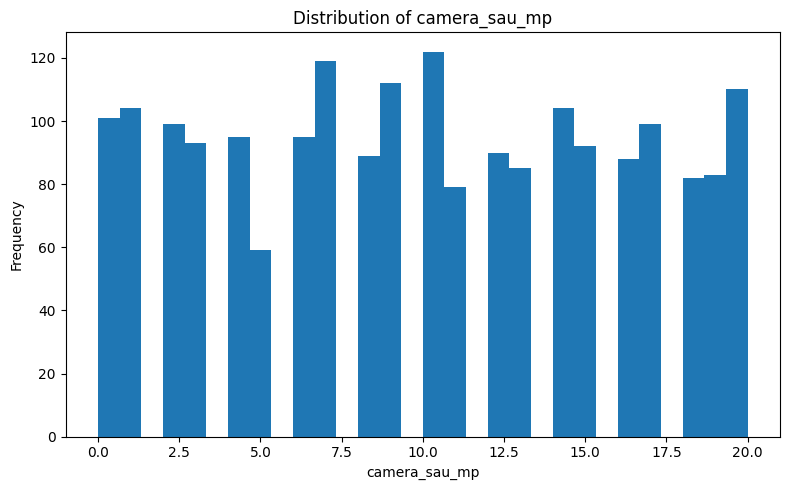

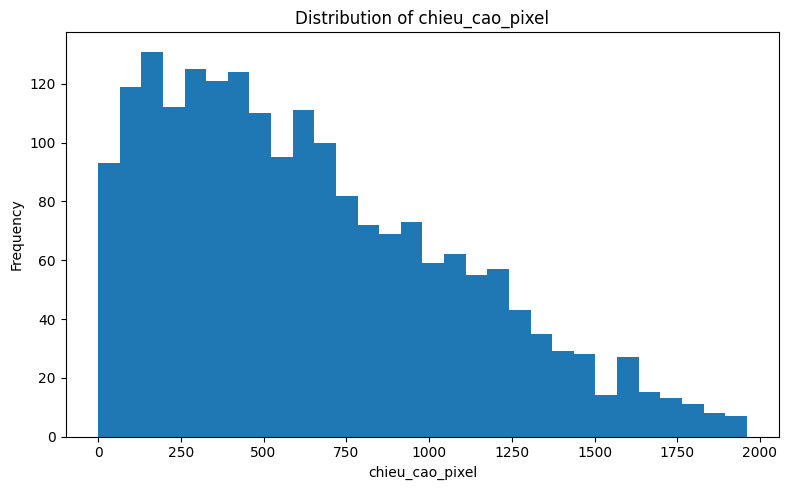

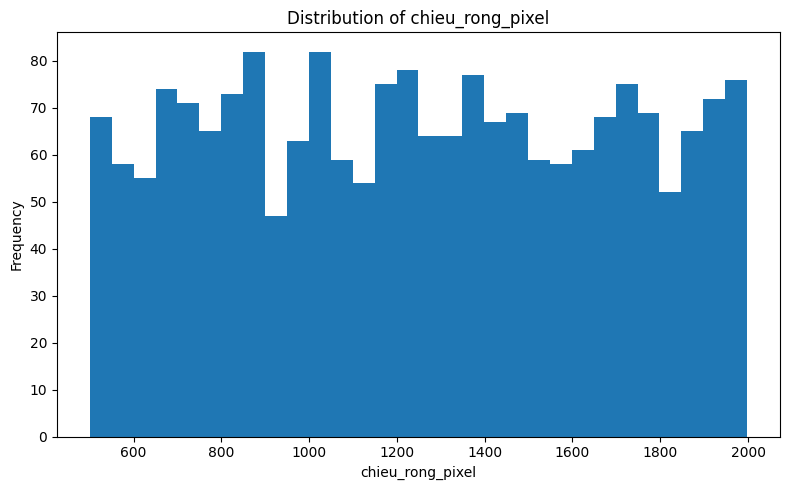

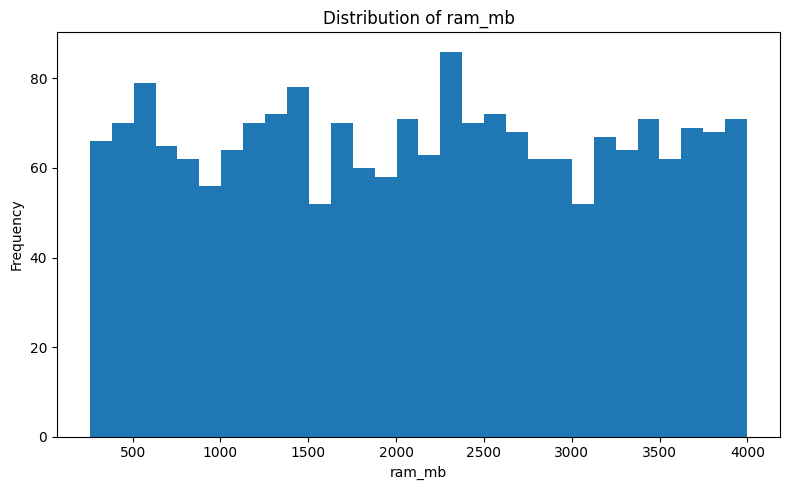

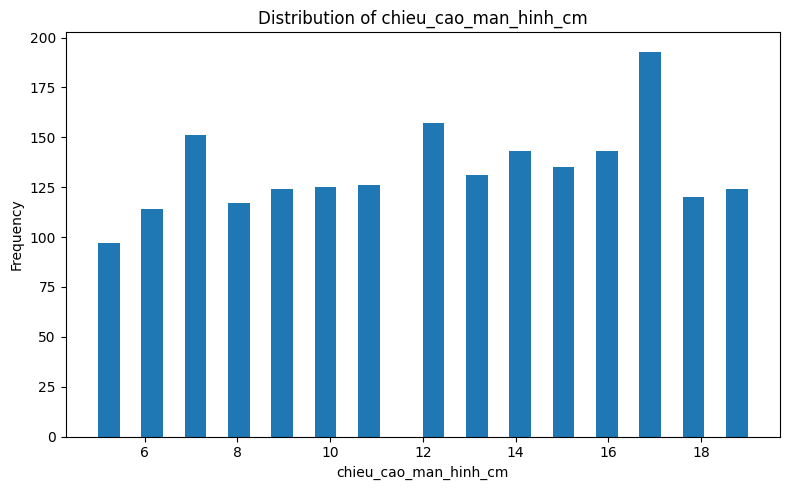

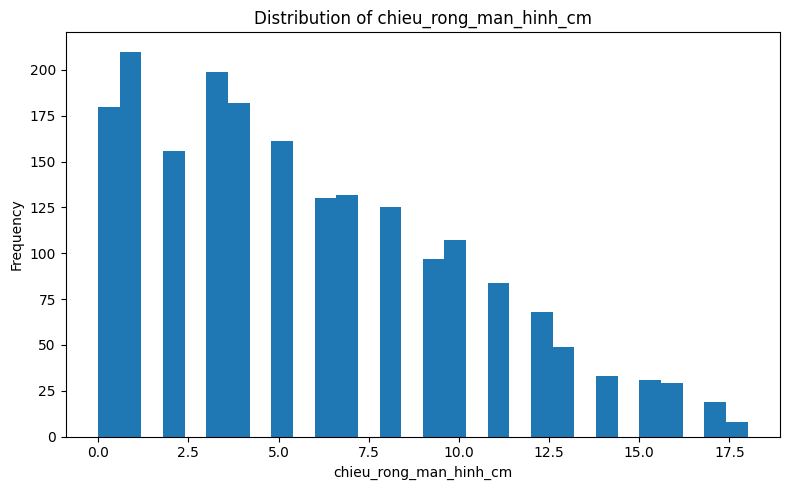

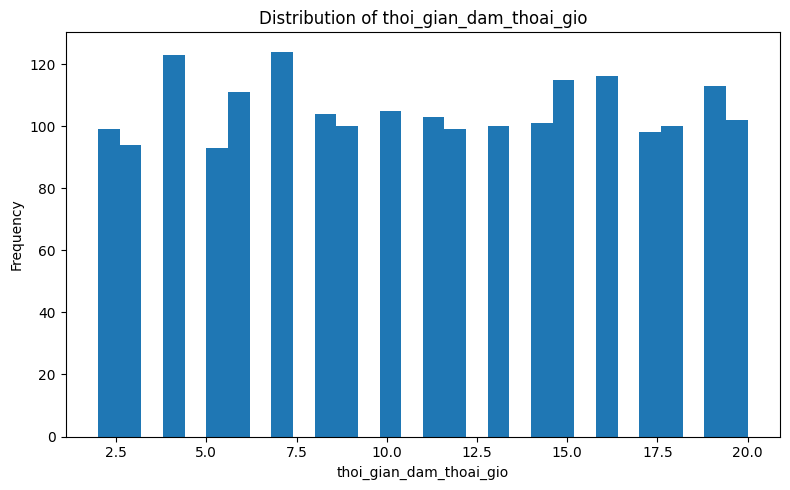

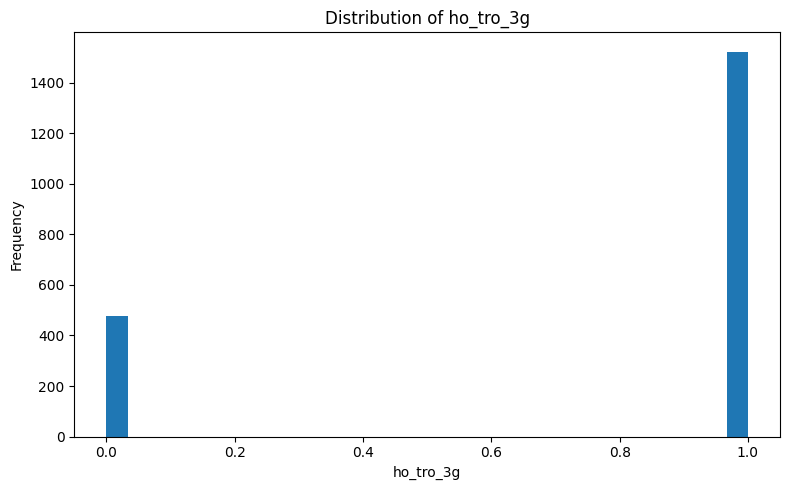

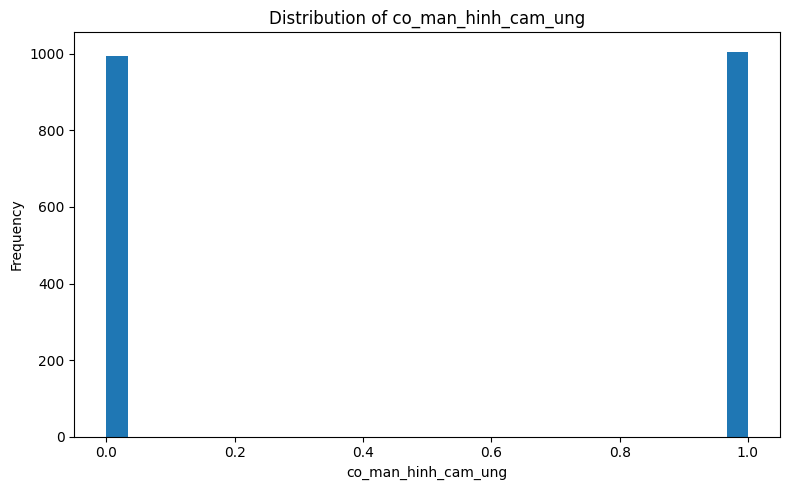

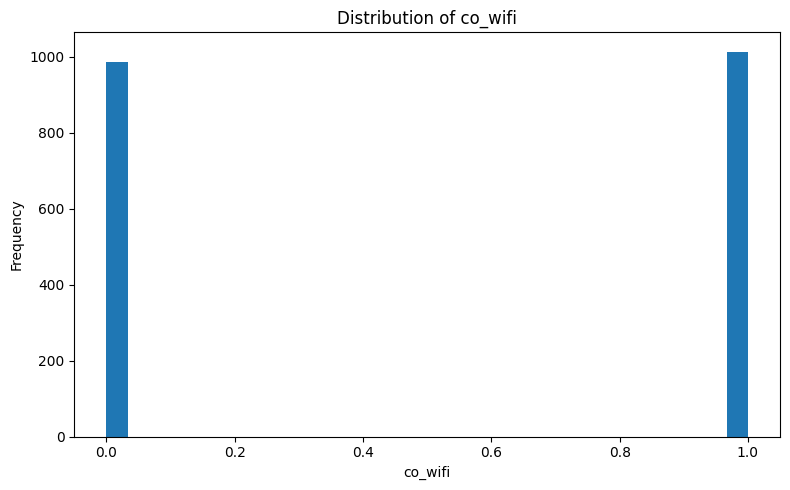

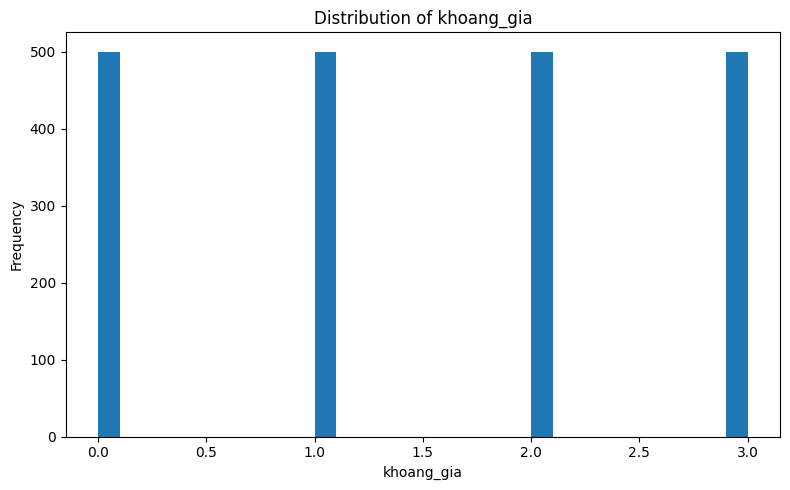

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Thư mục lưu ảnh
output_dir = '/content/drive/MyDrive/AI_model/figure/evaluation'
os.makedirs(output_dir, exist_ok=True)

# Vẽ và lưu từng histogram
for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    plt.hist(train_vn[col].dropna(), bins=30)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()

    # Lưu từng ảnh
    plt.savefig(
        f'{output_dir}/hist_{col}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()

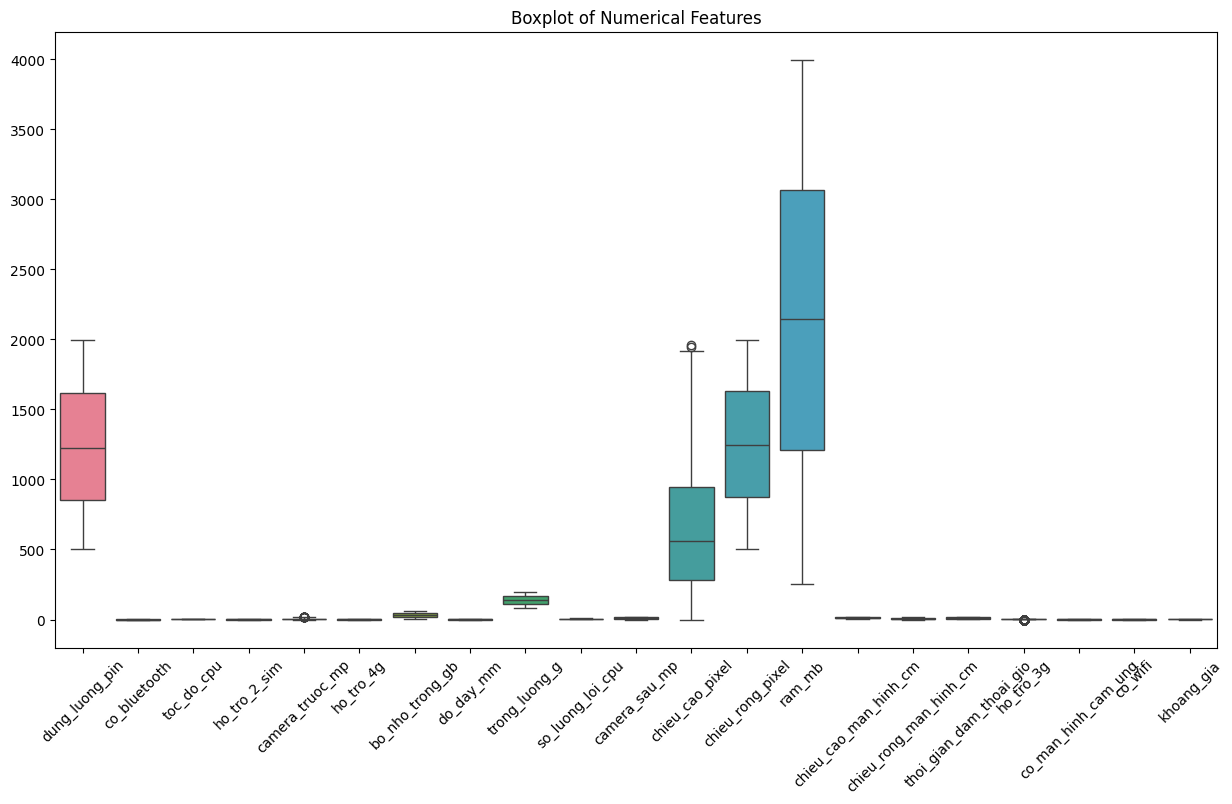

In [ ]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=train_vn[numeric_cols])

plt.xticks(rotation=45)
plt.title('Boxplot of Numerical Features')
plt.show()

### Lưu các biểu đồ

In [ ]:
import os

# Define the base path for hocMay and the figure directory
hocmay_path = '/content/drive/MyDrive/AI_model'
figure_path = os.path.join(hocmay_path, 'figure')

# Create the directories if they don't exist
os.makedirs(figure_path, exist_ok=True)

print(f"Đã tạo thư mục: {figure_path}")

Đã tạo thư mục: /content/drive/MyDrive/AI_model/figure


In [ ]:
# Save Histogram plot
hist_fig = train_vn[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
hist_fig = plt.gcf() # Get current figure
hist_path = os.path.join(figure_path, 'numerical_features_histogram.png')
hist_fig.savefig(hist_path)
print(f"Biểu đồ Histogram đã được lưu tại: {hist_path}")
plt.close(hist_fig) # Close the figure to avoid displaying it again

Biểu đồ Histogram đã được lưu tại: /content/drive/MyDrive/AI_model/figure/numerical_features_histogram.png


In [ ]:
# Save Boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(data=train_vn[numeric_cols])
plt.xticks(rotation=45)
plt.title('Boxplot of Numerical Features')
boxplot_path = os.path.join(figure_path, 'numerical_features_boxplot.png')
plt.savefig(boxplot_path)
print(f"Biểu đồ Boxplot đã được lưu tại: {boxplot_path}")
plt.close() # Close the figure

Biểu đồ Boxplot đã được lưu tại: /content/drive/MyDrive/AI_model/figure/numerical_features_boxplot.png


In [ ]:
categorical_cols = train.select_dtypes(
    include=['object', 'category']
).columns

print(categorical_cols)

Index([], dtype='object')


In [ ]:
for col in categorical_cols:
    print(f"\n{col}")
    print(train[col].value_counts())

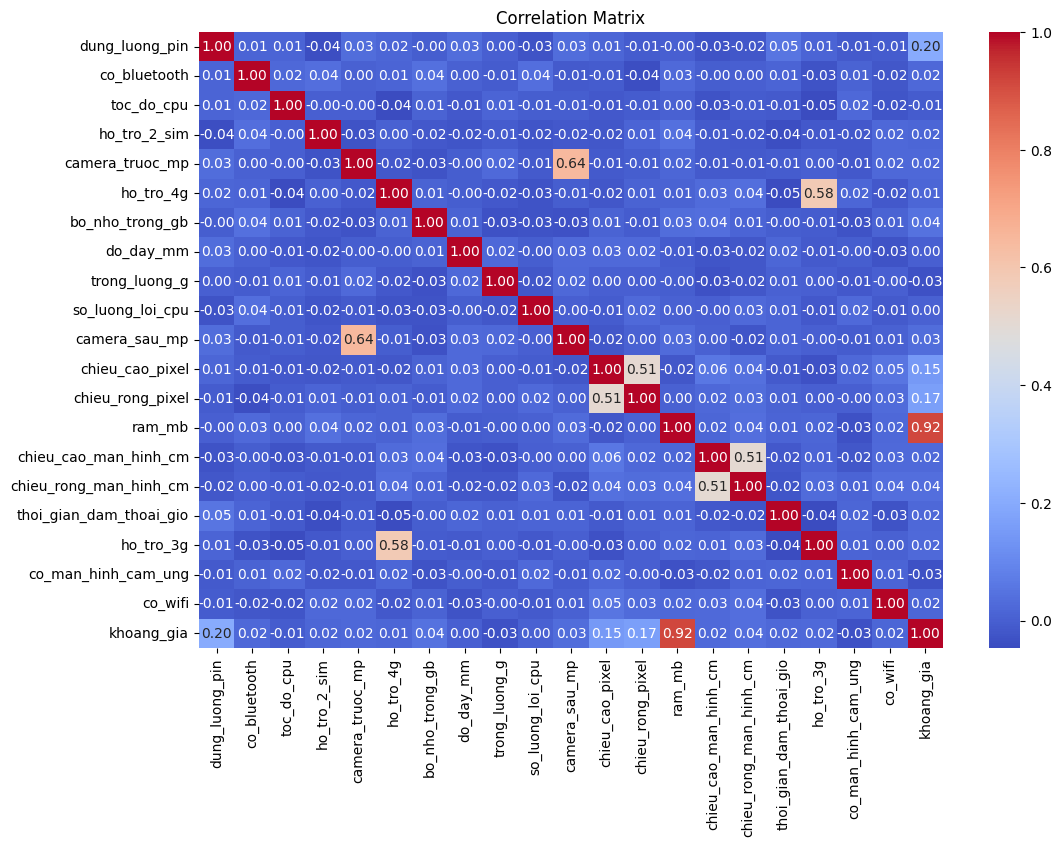

In [ ]:
corr = train_vn[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
target = 'khoang_gia'

In [ ]:
train_vn[target].value_counts()

,count
khoang_gia,
1,500
2,500
3,500
0,500


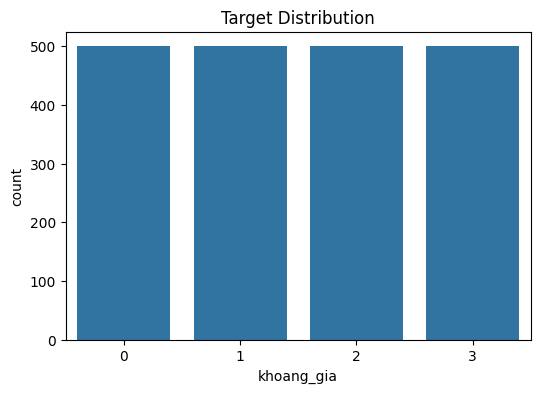

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train_vn, x=target)

plt.title('Target Distribution')
plt.show()

In [ ]:
train_vn[target].value_counts(normalize=True) * 100

,proportion
khoang_gia,
1,25.0
2,25.0
3,25.0
0,25.0


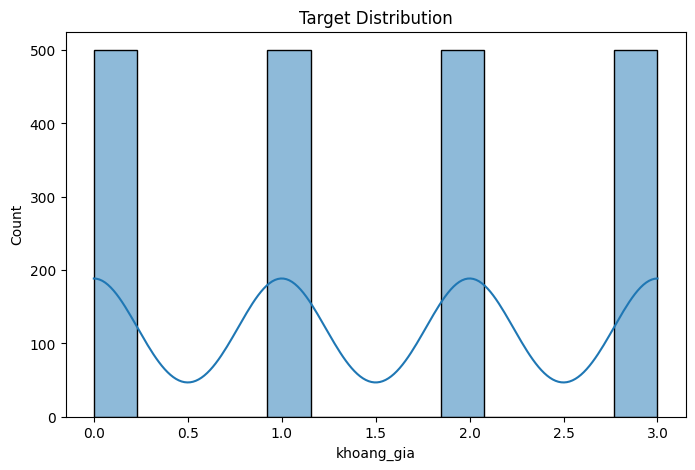

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(train_vn[target], kde=True)

plt.title('Target Distribution')
plt.show()

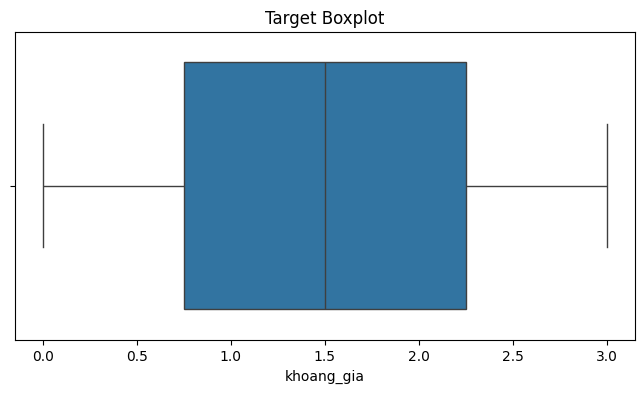

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=train_vn[target])

plt.title('Target Boxplot')
plt.show()